In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("SuperMarket.csv")
df["Date"]=pd.to_datetime(df["Date"])




In [51]:
df["Day"]=df["Date"].dt.day_name()

In [52]:
df["Day"]=df["Date"].dt.day_name()
day_sale=df.groupby("Day") ["Sales"].sum().sort_values(ascending=False)
print(day_sale)

Day
Saturday     56120.8095
Tuesday      51482.2455
Thursday     45349.2480
Sunday       44457.8925
Friday       43926.3405
Wednesday    43731.1350
Monday       37899.0780
Name: Sales, dtype: float64


In [53]:
# product_wise_revenue
mostselled_products=df.groupby("Product line") ["Sales"].sum().sort_values(ascending=False)
print(mostselled_products)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64


In [54]:
# Product wise quantity
mostselled_qty=df.groupby("Product line")["Quantity"].sum()
print(mostselled_qty)

Product line
Electronic accessories    971
Fashion accessories       902
Food and beverages        952
Health and beauty         854
Home and lifestyle        911
Sports and travel         920
Name: Quantity, dtype: int64


In [55]:
# Product sales by day
product_day_sale=df.groupby(["Product line","Day"])["Sales"].sum().unstack()
print(product_day_sale)

Day                        Friday     Monday    Saturday      Sunday  \
Product line                                                           
Electronic accessories  4848.1545  5922.1260   9744.3780   6411.8775   
Fashion accessories     9554.7585  6419.5215  10778.9220   5583.7425   
Food and beverages      4558.4280  6612.2280   9375.3975   7763.4165   
Health and beauty       8331.0150  8448.2370   7410.3435   4973.3355   
Home and lifestyle      6875.4210  6095.3445   9208.0065  12072.2910   
Sports and travel       9758.5635  4401.6210   9603.7620   7653.2295   

Day                       Thursday     Tuesday   Wednesday  
Product line                                                
Electronic accessories  12435.1605  10110.9225   4864.9125  
Fashion accessories      7725.8895   7423.2795   6819.7815  
Food and beverages       6798.5925   9848.2965  11188.4850  
Health and beauty        5582.4720   8559.5895   5888.7465  
Home and lifestyle       5427.3030   7708.7325   6474.814

In [56]:
print(df.columns)

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating', 'Day'],
      dtype='str')


In [57]:
payment=df.groupby("Payment")["Sales"].sum()
print(payment)

Payment
Cash           112206.570
Credit card    100767.072
Ewallet        109993.107
Name: Sales, dtype: float64


In [58]:
gender=df.groupby("Gender")["Sales"].sum()
print(gender)

Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64


In [59]:
df["Time"]=pd.to_datetime(df["Time"],format="%I:%M:%S %p")

In [60]:
def get_time_period(time):
  hour=time.hour
  if 6<=hour<12:
    return "Morning"
  elif 12<=hour<17:
    return "Afternoon"
  elif 17<=hour<=21:
    return "Evening"
  else:
    return "Night"


In [61]:
df["Time_period"]=df["Time"].apply(get_time_period)


In [62]:
time_sale=df.groupby("Time_period")["Sales"].sum()
print(time_sale)

Time_period
Afternoon    148023.3405
Evening      113144.5980
Morning       61798.8105
Name: Sales, dtype: float64


In [63]:
average_basket_size=df["Sales"].mean()
print(average_basket_size)

322.966749


In [64]:
customer_type=df.groupby("Customer type")["Sales"].mean()
print(customer_type)

Customer type
Member    335.742945
Normal    306.372379
Name: Sales, dtype: float64


In [65]:
city_salees=df.groupby("City")["Sales"].sum()
print(city_salees)

City
Mandalay     106197.6720
Naypyitaw    110568.7065
Yangon       106200.3705
Name: Sales, dtype: float64


In [66]:
city_data=df["City"]
print(city_data)

0         Yangon
1      Naypyitaw
2         Yangon
3         Yangon
4         Yangon
         ...    
995    Naypyitaw
996     Mandalay
997       Yangon
998       Yangon
999       Yangon
Name: City, Length: 1000, dtype: str


In [67]:
Branch=df["Branch"]
print(Branch)

0       Alex
1       Giza
2       Alex
3       Alex
4       Alex
       ...  
995     Giza
996    Cairo
997     Alex
998     Alex
999     Alex
Name: Branch, Length: 1000, dtype: str


In [68]:
branch_sale=df.groupby("Branch")["Sales"].sum()
print(branch_sale)

Branch
Alex     106200.3705
Cairo    106197.6720
Giza     110568.7065
Name: Sales, dtype: float64


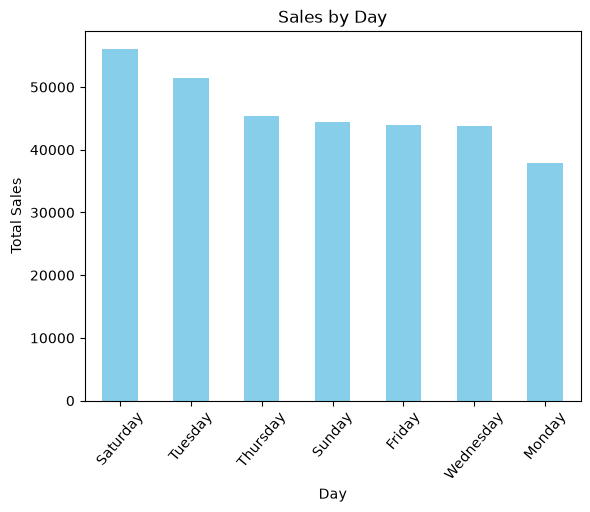

In [69]:
day_sale.plot(kind="bar",color="skyblue")
plt.title("Sales by Day")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=50)
plt.show()

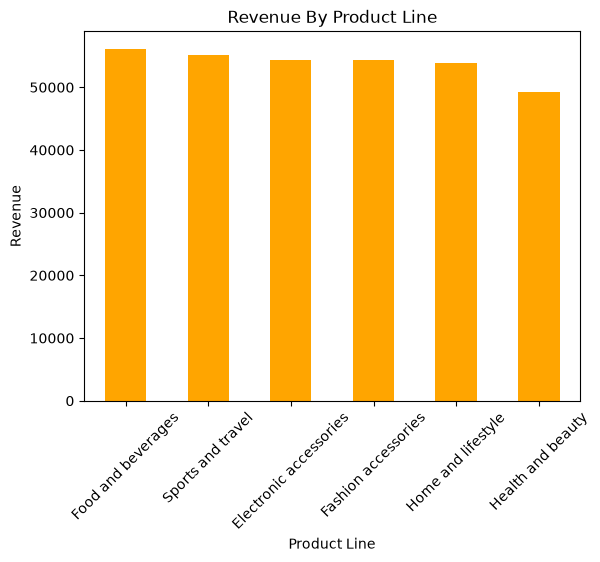

In [70]:
mostselled_products.plot(kind="bar",color="orange")
plt.title("Revenue By Product Line")
plt.xlabel("Product Line")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

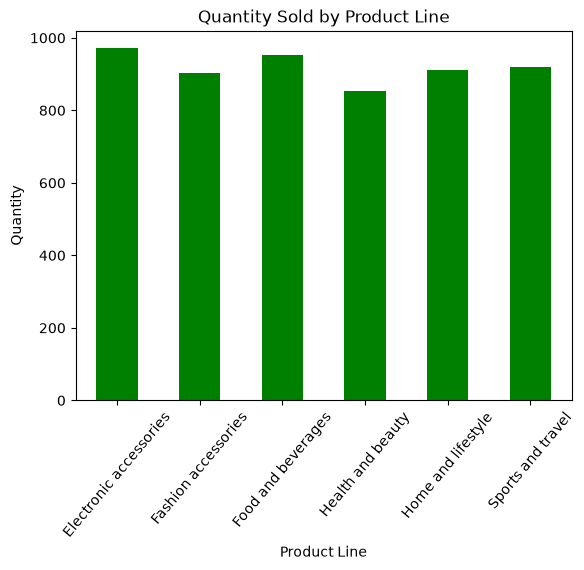

In [71]:
mostselled_qty.plot(kind="bar",color="green")
plt.title("Quantity Sold by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Quantity")
plt.xticks(rotation=50)
plt.show()

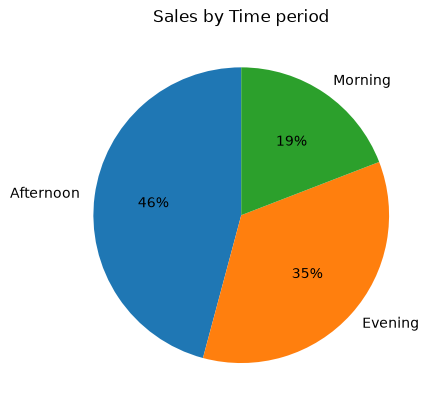

In [72]:
time_sale.plot(kind="pie",autopct="%1.0f%%",startangle=90)
plt.title("Sales by Time period")
plt.ylabel("")
plt.show()

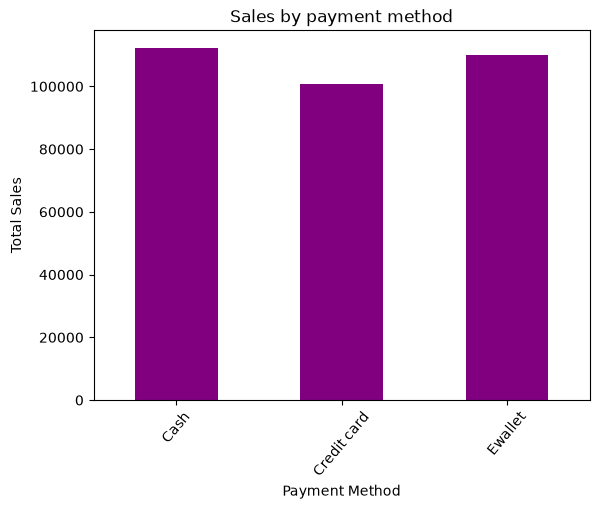

In [73]:
payment.plot(kind="bar",color="purple")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.title("Sales by payment method")
plt.xticks(rotation=50)
plt.show()

Text(0, 0.5, 'Total sales')

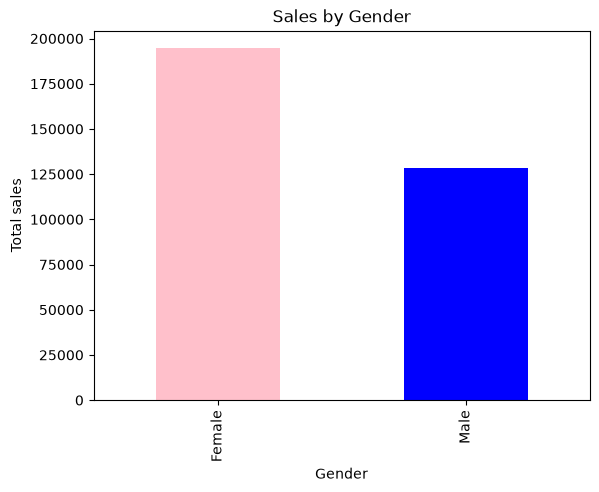

In [74]:
gender.plot(kind="bar",color=["pink","blue"])
plt.title("Sales by Gender")
plt.ylabel("Total sales")

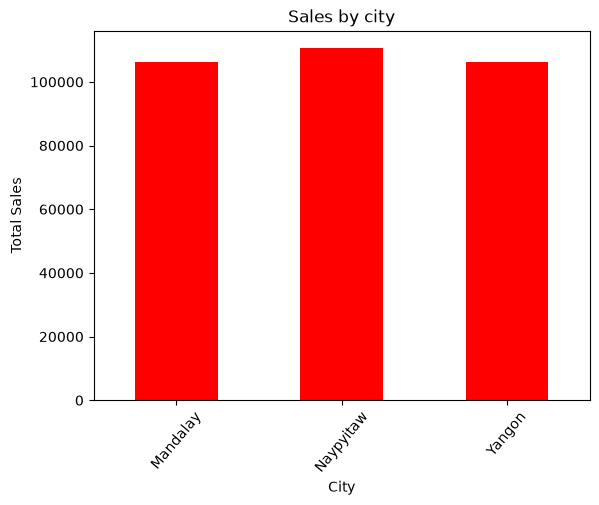

In [75]:
city_salees.plot(kind="bar",color="red")
plt.title("Sales by city")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=50)
plt.show()

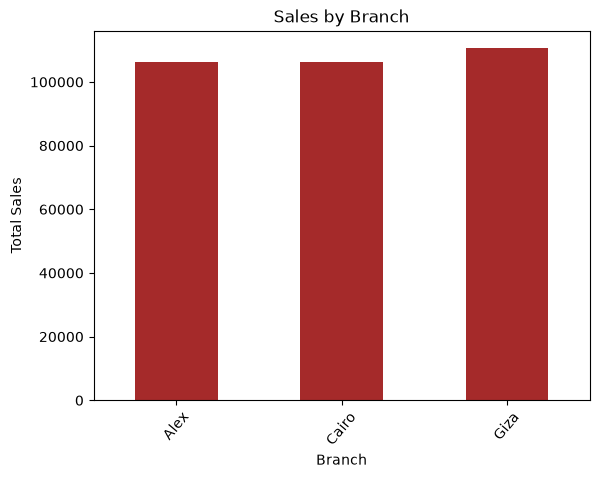

In [76]:
branch_sale.plot(kind="bar",color="brown")
plt.title("Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.xticks(rotation=50)
plt.show()

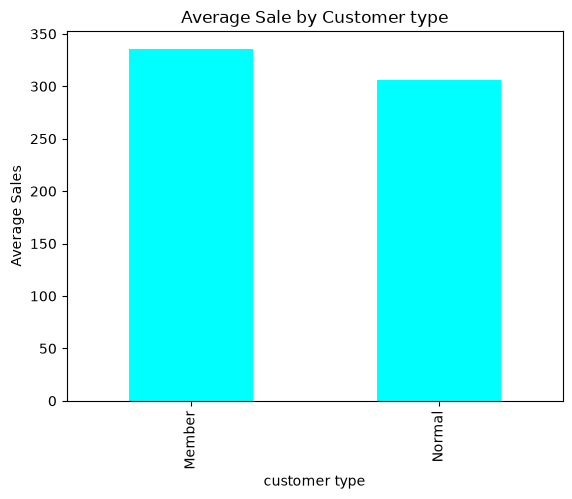

In [77]:
customer_type.plot(kind="bar", color="cyan")
plt.title("Average Sale by Customer type")
plt.xlabel("customer type")
plt.ylabel("Average Sales")
plt.show()

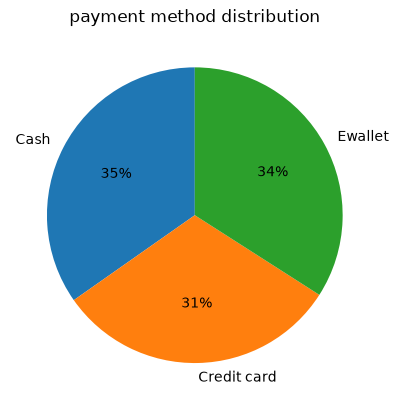

In [78]:
payment.plot(kind="pie",autopct="%1.0f%%",startangle=90)
plt.title("payment method distribution")
plt.ylabel("")
plt.show()

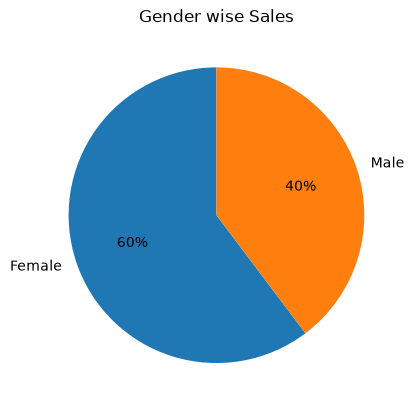

In [79]:
gender.plot(kind="pie",autopct="%1.0f%%",startangle=90)
plt.title("Gender wise Sales")
plt.ylabel("")
plt.show()

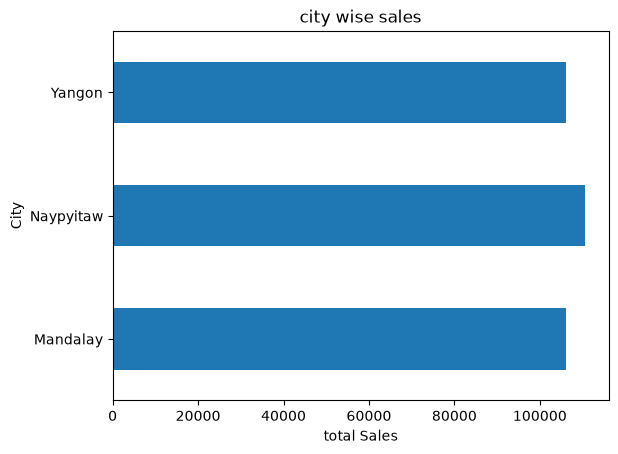

In [80]:
city_salees.plot(kind="barh")
plt.title("city wise sales")
plt.xlabel("total Sales")
plt.ylabel("City")

plt.show()

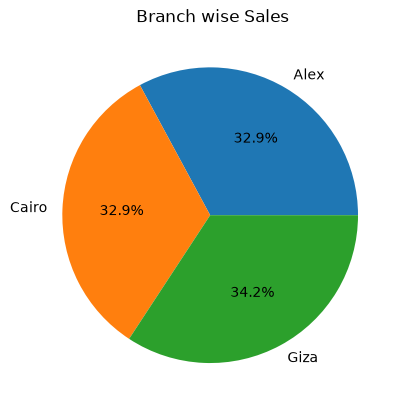

In [81]:
branch_sale.plot(kind="pie",autopct="%1.1f%%")
plt.title(" Branch wise Sales")

plt.ylabel("")

plt.show()

In [82]:
daily_sales=df.groupby("Date")["Sales"].sum()

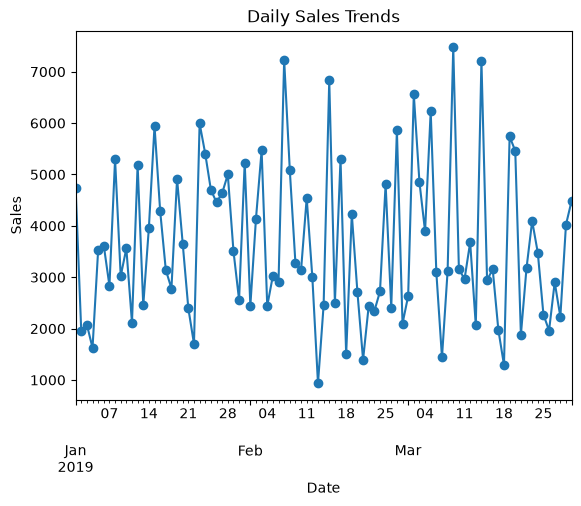

In [83]:
daily_sales.plot(kind="line",marker="o")
plt.title("Daily Sales Trends")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()